In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Split dataset dengan stratified k-fold dengan k=5

In [ ]:
import os
import shutil
import numpy as np
from glob import glob
from sklearn.model_selection import StratifiedKFold

# Path dataset
raw_dataset_path = '/content/drive/MyDrive/sindikia_ta/newdataset/cataract_split/train'
split_dataset_path = '/content/drive/MyDrive/sindikia_ta/newdataset/kfoldsplit_dataset'
os.makedirs(split_dataset_path, exist_ok=True)

# Ambil gambar dan label
file_paths, labels = [], []
classes = sorted(os.listdir(raw_dataset_path))

for idx, class_name in enumerate(classes):
    class_folder = os.path.join(raw_dataset_path, class_name)
    for file_path in glob(os.path.join(class_folder, '*')):
        file_paths.append(file_path)
        labels.append(idx)

file_paths = np.array(file_paths)
labels = np.array(labels)

# Split k-fold
print("Membagi dataset dengan menggunakan stratified K-Fold ...")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold_num, (train_idx, test_idx) in enumerate(skf.split(file_paths, labels), start=1):
    print(f"\nFold {fold_num} :")

    fold_train_dir = os.path.join(split_dataset_path, f'fold_{fold_num}', 'train')
    fold_test_dir = os.path.join(split_dataset_path, f'fold_{fold_num}', 'test')

    for label_idx, class_name in enumerate(classes):
        os.makedirs(os.path.join(fold_train_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(fold_test_dir, class_name), exist_ok=True)

    for idx in train_idx:
        src = file_paths[idx]
        dst = os.path.join(fold_train_dir, classes[labels[idx]], os.path.basename(src))
        shutil.copy2(src, dst)

    for idx in test_idx:
        src = file_paths[idx]
        dst = os.path.join(fold_test_dir, classes[labels[idx]], os.path.basename(src))
        shutil.copy2(src, dst)

    print(f"Data Training  : {len(train_idx)}")
    print(f"Data Testing  : {len(test_idx)}")

print("\n✅ Proses selesai.")

Membagi dataset dengan menggunakan stratified K-Fold ...

Fold 1 :
Data Training  : 237
Data Testing  : 60

Fold 2 :
Data Training  : 237
Data Testing  : 60

Fold 3 :
Data Training  : 238
Data Testing  : 59

Fold 4 :
Data Training  : 238
Data Testing  : 59

Fold 5 :
Data Training  : 238
Data Testing  : 59

✅ Proses selesai.


Preprocessing data >> melakukan augmentasi pada det training

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import cv2
import numpy as np
import random
from glob import glob
from tqdm import tqdm

# Konfigurasi
IMG_SIZE = 416
FOLDS = 5

split_dataset_path = '/content/drive/MyDrive/sindikia_ta/newdataset/kfoldsplit_dataset'
aug_dataset_path = '/content/drive/MyDrive/sindikia_ta/newdataset/augment_result'

os.makedirs(aug_dataset_path, exist_ok=True)

# Fungsi augmentasi
def augmentations(img):

    # 1. Flip horizontal
    yield cv2.flip(img, 1)

    # 2. Flip vertical
    yield cv2.flip(img, 0)

    # 3. Random rotation
    angle = random.uniform(-90, 90)
    M = cv2.getRotationMatrix2D((IMG_SIZE // 2, IMG_SIZE // 2), angle, 1.0)
    rotated = cv2.warpAffine(
        img, M, (IMG_SIZE, IMG_SIZE),
        borderMode=cv2.BORDER_REFLECT
    )
    yield rotated

    # 4. CLAHE
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=1.2, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge((l_clahe, a, b))
    clahe_img = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)
    yield clahe_img

    # 5. Random crop
    crop_size = int(IMG_SIZE * 0.95)
    x = random.randint(0, IMG_SIZE - crop_size)
    y = random.randint(0, IMG_SIZE - crop_size)
    cropped = img[y:y + crop_size, x:x + crop_size]
    cropped = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE))
    yield cropped


#LOOP SIMPAN DATASET
for fold in os.listdir(split_dataset_path):
    fold_path = os.path.join(split_dataset_path, fold)

    for split in ["train", "test"]:
        split_path = os.path.join(fold_path, split)

        for cls in os.listdir(split_path):
            input_folder = os.path.join(split_path, cls)
            output_folder = os.path.join(aug_dataset_path, fold, split, cls)
            os.makedirs(output_folder, exist_ok=True)

            files = glob(os.path.join(input_folder, "*"))
            print(f"Processing: {fold}/{split}/{cls}, total: {len(files)}")

            for idx, file in enumerate(files):
                img = cv2.imread(file)
                if img is None:
                    print(f"⚠️ Gagal baca gambar: {file}")
                    continue

                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                # Simpan original (train & test)
                base_name = f"{cls}_{idx}_orig.jpg"
                cv2.imwrite(os.path.join(output_folder, base_name), img)

                # Augmentasi hanya TRAIN
                if split == "train":
                    for j, aug_img in enumerate(augmentations(img)):
                        aug_name = f"{cls}_{idx}_aug{j+1}.jpg"
                        cv2.imwrite(os.path.join(output_folder, aug_name), aug_img)

print("✅ Augmentasi selesai — hanya folder TRAIN yang diaugmentasi.")

Processing: fold_1/train/immature, total: 60
Processing: fold_1/train/mature, total: 92
Processing: fold_1/train/normal, total: 85
Processing: fold_1/test/immature, total: 16
Processing: fold_1/test/mature, total: 23
Processing: fold_1/test/normal, total: 21
Processing: fold_2/train/immature, total: 61
Processing: fold_2/train/mature, total: 92
Processing: fold_2/train/normal, total: 84
Processing: fold_2/test/immature, total: 15
Processing: fold_2/test/mature, total: 23
Processing: fold_2/test/normal, total: 22
Processing: fold_3/train/immature, total: 61
Processing: fold_3/train/mature, total: 92
Processing: fold_3/train/normal, total: 85
Processing: fold_3/test/immature, total: 15
Processing: fold_3/test/mature, total: 23
Processing: fold_3/test/normal, total: 21
Processing: fold_4/train/immature, total: 61
Processing: fold_4/train/mature, total: 92
Processing: fold_4/train/normal, total: 85
Processing: fold_4/test/immature, total: 15
Processing: fold_4/test/mature, total: 23
Proces

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Implementasi model resnet-50

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping

#Konfigurasi
img_size = 224
EPOCH = 30
num_folds = 5

learning_rates = [1e-5, 1e-4]
batch_sizes = [32, 64]
optimizers = ["Adam", "RMSprop"]

base_path = "/content/drive/MyDrive/sindikia_ta/newdataset/augment_result"

save_model_path = "/content/drive/MyDrive/sindikia_ta/newdataset/model_results_resnet50"
save_plot_path = "/content/drive/MyDrive/sindikia_ta/newdataset/grafik_resnet50"
save_cm_path   = "/content/drive/MyDrive/sindikia_ta/newdataset/confusion_matrix_resnet50"
save_excel_path = "/content/drive/MyDrive/sindikia_ta/newdataset/final_scores_resnet50.xlsx"

os.makedirs(save_plot_path, exist_ok=True)
os.makedirs(save_cm_path, exist_ok=True)
os.makedirs(save_model_path, exist_ok=True)

results = []

In [ ]:
def build_model(num_classes, lr, optimizer_name):
    base_model = ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(img_size, img_size, 3)
    )

    # Freeze semua
    for layer in base_model.layers:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x = BatchNormalization()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation="softmax")(x)

    model = Model(base_model.input, output)

    # Optimizer
    if optimizer_name == "Adam":
        optimizer = Adam(learning_rate=lr)
    else:
        optimizer = RMSprop(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
#training loop
exp = 1

for fold in range(1, num_folds + 1):

    print(f"      TRAINING FOLD {fold}      ")

    train_path = f"{base_path}/fold_{fold}/train"
    test_path  = f"{base_path}/fold_{fold}/test"

    train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
    test_gen  = ImageDataGenerator(preprocessing_function=preprocess_input)

    tmp = train_gen.flow_from_directory(
        train_path,
        target_size=(img_size, img_size),
        batch_size=1,
        class_mode="categorical"
    )
    num_classes = tmp.num_classes
    class_names = list(tmp.class_indices.keys())

    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(tmp.classes),
        y=tmp.classes
    )
    class_weights = dict(enumerate(class_weights))

    # LOOP HYPERPARAMETER
    for opt in optimizers:
        for lr in learning_rates:
            for bs in batch_sizes:

                print(f"\n▶ EXPERIMENT {exp} | Fold= {fold}, OPT= {opt}, LR= {lr}, BS= {bs}")

                train_data = train_gen.flow_from_directory(
                    train_path,
                    target_size=(img_size, img_size),
                    batch_size=bs,
                    class_mode="categorical"
                )

                test_data = test_gen.flow_from_directory(
                    test_path,
                    target_size=(img_size, img_size),
                    batch_size=bs,
                    class_mode="categorical",
                    shuffle=False
                )

                # BUILD MODEL
                model = build_model(num_classes, lr, opt)

                es = EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)

                # TRAIN
                start_time = time.time()

                history = model.fit(
                    train_data,
                    epochs=EPOCH,
                    validation_data=test_data,
                    class_weight=class_weights,
                    callbacks=[es],
                    verbose=1
                )
                end_time = time.time()
                train_time = end_time - start_time

                # SAVE MODEL
                model_filename = f"fold{fold}_exp{exp}_{opt}_lr{lr}_bs{bs}.h5"
                model.save(f"{save_model_path}/{model_filename}")

                # SAVE TRAINING PLOT
                plt.figure(figsize=(12,5))

                # LOSS
                plt.subplot(1,2,1)
                plt.plot(history.history['loss'], label='Train Loss')
                plt.plot(history.history['val_loss'], label='Val Loss')
                plt.title(f"Loss Fold {fold} Exp {exp}")
                plt.legend()

                # ACCURACY
                plt.subplot(1,2,2)
                plt.plot(history.history['accuracy'], label='Train Acc')
                plt.plot(history.history['val_accuracy'], label='Val Acc')
                plt.title(f"Accuracy Fold {fold} Exp {exp}")
                plt.legend()

                plt.tight_layout()
                plt.savefig(f"{save_plot_path}/fold{fold}_exp{exp}.png")
                plt.close()

                # CONFUSION MATRIX
                preds = model.predict(test_data)
                y_pred = np.argmax(preds, axis=1)
                y_true = test_data.classes

                cm = confusion_matrix(y_true, y_pred)

                plt.figure(figsize=(6,5))
                sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                            xticklabels=class_names, yticklabels=class_names)
                plt.title(f"Confusion Matrix Fold {fold} Exp {exp}")
                plt.xlabel("Predicted")
                plt.ylabel("True")

                plt.savefig(f"{save_cm_path}/cm_fold{fold}_exp{exp}.png")
                plt.close()

                # EVALUATION
                acc = accuracy_score(y_true, y_pred)
                prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
                rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
                f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

                results.append([
                    fold, exp, opt, lr, bs, acc, prec, rec, f1, train_time
                ])

                exp += 1

      TRAINING FOLD 1      
Found 1422 images belonging to 3 classes.

▶ EXPERIMENT 1 | Fold= 1, OPT= Adam, LR= 1e-05, BS= 32
Found 1422 images belonging to 3 classes.
Found 60 images belonging to 3 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 461ms/step - accuracy: 0.4222 - loss: 1.4215 - val_accuracy: 0.4333 - val_loss: 1.1657
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 148ms/step - accuracy: 0.5074 - loss: 1.1707 - val_accuracy: 0.5167 - val_loss: 1.0157
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 147ms/step - accuracy: 0.5645 - loss: 1.0664 - val_accuracy: 0.6167 - val_loss: 0.8901
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 147ms/step - accuracy: 0.6377 - loss: 0.9293 - val_accuracy: 0.6833 - val_loss: 0.8016
Epoch 5/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 150ms/step - accuracy: 0.6658 - loss: 0.8002 - val_accuracy: 0.7000 - val_loss: 0.7384
Epoch 6/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 149ms/step - accuracy: 0.6522 - loss: 0.7953 - val_accuracy: 0.7000 - val_loss: 0.6817
Epoch 7/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 149ms/step - accuracy: 0.6829 - loss: 0.7619 - val_accuracy: 0.6667 - val_loss: 0.6403
Epoch 8/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 154ms/step - accuracy: 0.7166 - loss: 0.6944 - val_accuracy: 0

2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step

▶ EXPERIMENT 2 | Fold= 1, OPT= Adam, LR= 1e-05, BS= 64
Found 1422 images belonging to 3 classes.
Found 60 images belonging to 3 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


...

Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 27s 378ms/step - accuracy: 0.5495 - loss: 1.0133 - val_accuracy: 0.7288 - val_loss: 0.5786
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 157ms/step - accuracy: 0.8288 - loss: 0.4286 - val_accuracy: 0.8136 - val_loss: 0.5097
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 154ms/step - accuracy: 0.8622 - loss: 0.3217 - val_accuracy: 0.8305 - val_loss: 0.4588
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - accuracy: 0.9263 - loss: 0.2102 - val_accuracy: 0.8305 - val_loss: 0.4554
Epoch 5/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 147ms/step - accuracy: 0.9475 - loss: 0.1539 - val_accuracy: 0.8305 - val_loss: 0.4401
Epoch 6/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - accuracy: 0.9494 - loss: 0.1369 - val_accuracy: 0.8136 - val_loss: 0.4895
Epoch 7/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 147ms/step - accuracy: 0.9745 - loss: 0.0870 - val_accuracy: 0.8305 - val_loss: 0.5474
Epoch 8/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 149ms/step - accuracy: 0.9830 - loss: 0.0631 - val_accuracy: 0

2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 7s/step

▶ EXPERIMENT 40 | Fold= 5, OPT= RMSprop, LR= 0.0001, BS= 64
Found 1428 images belonging to 3 classes.
Found 59 images belonging to 3 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 28s 739ms/step - accuracy: 0.4772 - loss: 1.1606 - val_accuracy: 0.7966 - val_loss: 0.6548
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 312ms/step - accuracy: 0.7415 - loss: 0.5994 - val_accuracy: 0.8475 - val_loss: 0.4804
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 305ms/step - accuracy: 0.8560 - loss: 0.3656 - val_accuracy: 0.8644 - val_loss: 0.4133
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 311ms/step - accuracy: 0.8921 - loss: 0.2825 - val_accuracy: 0.8644 - val_loss: 0.3784
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 333ms/step - accuracy: 0.9267 - loss: 0.2121 - val_accuracy: 0.8475 - val_loss: 0.3630
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 320ms/step - accuracy: 0.9520 - loss: 0.1522 - val_accuracy: 0.8305 - val_loss: 0.3624
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 308ms/step - accuracy: 0.9445 - loss: 0.1356 - val_accuracy: 0.8305 - val_loss: 0.3621
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 321ms/step - accuracy: 0.9647 - loss: 0.1047 - val_accuracy: 0

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [ ]:
# SAVE ALL RESULTS TO EXCEL
df = pd.DataFrame(results, columns=[
    "Fold", "Experiment", "Optimizer", "LR", "BatchSize",
    "Accuracy", "Precision", "Recall", "F1 Score","Training_Time_sec"
])

# AVERAGE PER HYPERPARAMETER COMBINATION
avg_per_combination = (
    df
    .groupby(["Optimizer", "LR", "BatchSize"])
    .agg(
        Mean_Accuracy=("Accuracy", "mean"),
        Std_Accuracy=("Accuracy", "std"),
        Mean_Precision=("Precision", "mean"),
        Mean_Recall=("Recall", "mean"),
        Mean_F1=("F1 Score", "mean"),
        Avg_Training_Time=("Training_Time_sec", "mean")
    )
    .reset_index()
)

#Overall Average
overall_avg = df[["Accuracy", "Precision", "Recall", "F1 Score"]].mean()

#Best per Fold (berdasarkan F1 Score)
best_per_fold = df.loc[df.groupby("Fold")["F1 Score"].idxmax()]

#Top 10 best experiments (global)
top10 = df.sort_values(["F1 Score", "Accuracy"], ascending=False).head(10)

#Best overall
best_overall = df.loc[df["F1 Score"].idxmax()]

#training time
avg_time_per_fold = df.groupby("Fold")["Training_Time_sec"].mean()
avg_time_overall = df["Training_Time_sec"].mean()

# SAVE ALL SHEETS
with pd.ExcelWriter(save_excel_path, engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name="All_Experiments", index=False)
    avg_per_combination.to_excel(
        writer,
        sheet_name="Avg_Per_Combination",
        index=False
    )

    overall_avg.to_frame().to_excel(writer, sheet_name="Overall_Average")
    best_per_fold.to_excel(writer, sheet_name="Best_Per_Fold", index=False)
    top10.to_excel(writer, sheet_name="Top10_Best", index=False)
    best_overall.to_frame().T.to_excel(writer, sheet_name="Best_Overall", index=False)

    avg_time_per_fold.to_excel(writer, sheet_name="Avg_Training_Time_Per_Fold")
    pd.DataFrame(
        [avg_time_overall],
        columns=["Avg_Training_Time_sec"]
    ).to_excel(
        writer,
        sheet_name="Avg_Training_Time_Overall",
        index=False
    )

print("\n==============================================")
print(" SEMUA TRAINING & ANALISIS SELESAI ✔")
print(f"📘 Excel           : {save_excel_path}")
print(f"📊 Grafik          : {save_plot_path}")
print(f"🔵 Confusion Matrix: {save_cm_path}")
print(f"💾 Model           : {save_model_path}")
print("==============================================")


 SEMUA TRAINING & ANALISIS SELESAI ✔
📘 Excel           : /content/drive/MyDrive/sindikia_ta/newdataset/final_scores_resnet50.xlsx
📊 Grafik          : /content/drive/MyDrive/sindikia_ta/newdataset/grafik_resnet50
🔵 Confusion Matrix: /content/drive/MyDrive/sindikia_ta/newdataset/confusion_matrix_resnet50
💾 Model           : /content/drive/MyDrive/sindikia_ta/newdataset/model_results_resnet50


Efficientnet-B3

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping

#Konfigurasi
img_size = 300
EPOCH = 30
num_folds = 5

learning_rates = [1e-5, 1e-4]
batch_sizes = [32, 64]
optimizers = ["Adam", "RMSprop"]

base_path = "/content/drive/MyDrive/sindikia_ta/newdataset/augment_result"

save_model_path = "/content/drive/MyDrive/sindikia_ta/newdataset/model_results_efficiennet"
save_plot_path  = "/content/drive/MyDrive/sindikia_ta/newdataset/grafik_efficiennet"
save_cm_path    = "/content/drive/MyDrive/sindikia_ta/newdataset/confusion_matrix_efficiennet"
save_excel_path = "/content/drive/MyDrive/sindikia_ta/newdataset/final_scores_efficiennet.xlsx"

os.makedirs(save_model_path, exist_ok=True)
os.makedirs(save_plot_path, exist_ok=True)
os.makedirs(save_cm_path, exist_ok=True)

results = []

In [ ]:
def build_model(num_classes, lr, optimizer_name):

    base_model = EfficientNetB3(
        include_top=False,
        weights="imagenet",
        input_shape=(img_size, img_size, 3)
    )

    # Freeze semua layer backbone
    for layer in base_model.layers:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x = BatchNormalization()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation="softmax")(x)

    model = Model(base_model.input, output)

    if optimizer_name == "Adam":
        optimizer = Adam(learning_rate=lr)
    else:
        optimizer = RMSprop(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
import time

exp = 1

for fold in range(1, num_folds + 1):

    print(f"\n====== TRAINING FOLD {fold} ======")

    train_path = f"{base_path}/fold_{fold}/train"
    test_path  = f"{base_path}/fold_{fold}/test"

    train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
    test_gen  = ImageDataGenerator(preprocessing_function=preprocess_input)

    tmp = train_gen.flow_from_directory(
        train_path,
        target_size=(img_size, img_size),
        batch_size=1,
        class_mode="categorical"
    )

    num_classes = tmp.num_classes
    class_names = list(tmp.class_indices.keys())

    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(tmp.classes),
        y=tmp.classes
    )
    class_weights = dict(enumerate(class_weights))

    for opt in optimizers:
        for lr in learning_rates:
            for bs in batch_sizes:

                print(f"\n▶ EXP {exp} | Fold= {fold}, OPT= {opt}, LR= {lr}, BS= {bs}")

                train_data = train_gen.flow_from_directory(
                    train_path,
                    target_size=(img_size, img_size),
                    batch_size=bs,
                    class_mode="categorical"
                )

                test_data = test_gen.flow_from_directory(
                    test_path,
                    target_size=(img_size, img_size),
                    batch_size=bs,
                    class_mode="categorical",
                    shuffle=False
                )

                model = build_model(num_classes, lr, opt)

                es = EarlyStopping(
                    monitor="val_loss",
                    patience=4,
                    restore_best_weights=True
                )

                start_time = time.time()
                history = model.fit(
                    train_data,
                    epochs=EPOCH,
                    validation_data=test_data,
                    class_weight=class_weights,
                    callbacks=[es],
                    verbose=1
                )
                end_time = time.time()
                train_time = end_time - start_time

                #SAVE MODEL
                model_name = f"fold{fold}_exp{exp}_{opt}_lr{lr}_bs{bs}.h5"
                model.save(os.path.join(save_model_path, model_name))

                #SAVE PLOT
                plt.figure(figsize=(12,5))

                plt.subplot(1,2,1)
                plt.plot(history.history["loss"], label="Train Loss")
                plt.plot(history.history["val_loss"], label="Val Loss")
                plt.title(f"Loss Fold {fold} Exp {exp}")
                plt.legend()

                plt.subplot(1,2,2)
                plt.plot(history.history["accuracy"], label="Train Acc")
                plt.plot(history.history["val_accuracy"], label="Val Acc")
                plt.title(f"Accuracy Fold {fold} Exp {exp}")
                plt.legend()

                plt.tight_layout()
                plt.savefig(f"{save_plot_path}/fold{fold}_exp{exp}.png")
                plt.close()

                #CONFUSION MATRIX
                preds = model.predict(test_data)
                y_pred = np.argmax(preds, axis=1)
                y_true = test_data.classes

                cm = confusion_matrix(y_true, y_pred)

                plt.figure(figsize=(6,5))
                sns.heatmap(
                    cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=class_names,
                    yticklabels=class_names
                )
                plt.title(f"CM Fold {fold} Exp {exp}")
                plt.xlabel("Predicted")
                plt.ylabel("True")
                plt.savefig(f"{save_cm_path}/cm_fold{fold}_exp{exp}.png")
                plt.close()

                #METRICS
                acc  = accuracy_score(y_true, y_pred)
                prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
                rec  = recall_score(y_true, y_pred, average="macro", zero_division=0)
                f1   = f1_score(y_true, y_pred, average="macro", zero_division=0)

                results.append([
                    fold, exp, opt, lr, bs, acc, prec, rec, f1, train_time
                ])
                exp += 1


====== TRAINING FOLD 1 ======
Found 1422 images belonging to 3 classes.

▶ EXP 1 | Fold= 1, OPT= Adam, LR= 1e-05, BS= 32
Found 1422 images belonging to 3 classes.
Found 60 images belonging to 3 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.3841 - loss: 2.1431 - val_accuracy: 0.4333 - val_loss: 1.1235
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 196ms/step - accuracy: 0.4133 - loss: 1.8091 - val_accuracy: 0.5500 - val_loss: 1.0563
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 196ms/step - accuracy: 0.4457 - loss: 1.6384 - val_accuracy: 0.5000 - val_loss: 1.0097
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 194ms/step - accuracy: 0.4912 - loss: 1.3670 - val_accuracy: 0.5167 - val_loss: 0.9749
Epoch 5/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 189ms/step - accuracy: 0.5535 - loss: 1.2067 - val_accuracy: 0.5833 - val_loss: 0.9492
Epoch 6/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 192ms/step - accuracy: 0.5558 - loss: 1.1113 - val_accuracy: 0.5667 - val_loss: 0.9191
Epoch 7/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 192ms/step - accuracy: 0.5932 - loss: 1.0432 - val_accuracy: 0.5833 - val_loss: 0.8930
Epoch 8/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 193ms/step - accuracy: 0.6050 - loss: 0.9521 - val_accuracy: 0.58

2/2 ━━━━━━━━━━━━━━━━━━━━ 23s 12s/step

▶ EXP 2 | Fold= 1, OPT= Adam, LR= 1e-05, BS= 64
Found 1422 images belonging to 3 classes.
Found 60 images belonging to 3 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


...

Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.4541 - loss: 1.1606 - val_accuracy: 0.5932 - val_loss: 0.7838
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 185ms/step - accuracy: 0.7190 - loss: 0.6508 - val_accuracy: 0.7288 - val_loss: 0.6586
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 192ms/step - accuracy: 0.7802 - loss: 0.5156 - val_accuracy: 0.7288 - val_loss: 0.5926
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 205ms/step - accuracy: 0.8148 - loss: 0.4364 - val_accuracy: 0.7627 - val_loss: 0.5405
Epoch 5/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 187ms/step - accuracy: 0.8491 - loss: 0.3731 - val_accuracy: 0.7797 - val_loss: 0.5145
Epoch 6/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 198ms/step - accuracy: 0.8536 - loss: 0.3708 - val_accuracy: 0.7458 - val_loss: 0.5004
Epoch 7/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 196ms/step - accuracy: 0.8736 - loss: 0.2993 - val_accuracy: 0.7288 - val_loss: 0.4985
Epoch 8/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 182ms/step - accuracy: 0.8804 - loss: 0.2760 - val_accuracy: 0.81

2/2 ━━━━━━━━━━━━━━━━━━━━ 24s 12s/step

▶ EXP 40 | Fold= 5, OPT= RMSprop, LR= 0.0001, BS= 64
Found 1428 images belonging to 3 classes.
Found 59 images belonging to 3 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.4661 - loss: 1.1621 - val_accuracy: 0.7797 - val_loss: 0.8081
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 379ms/step - accuracy: 0.6926 - loss: 0.7286 - val_accuracy: 0.7966 - val_loss: 0.7194
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 379ms/step - accuracy: 0.7580 - loss: 0.5879 - val_accuracy: 0.7797 - val_loss: 0.6552
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 380ms/step - accuracy: 0.7727 - loss: 0.5126 - val_accuracy: 0.7966 - val_loss: 0.5947
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 382ms/step - accuracy: 0.8263 - loss: 0.4381 - val_accuracy: 0.8136 - val_loss: 0.5483
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 372ms/step - accuracy: 0.8343 - loss: 0.4139 - val_accuracy: 0.8305 - val_loss: 0.5116
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 379ms/step - accuracy: 0.8539 - loss: 0.3315 - val_accuracy: 0.8136 - val_loss: 0.4760
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 380ms/step - accuracy: 0.8909 - loss: 0.2865 - val_accuracy: 0.81

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


In [ ]:
# SAVE ALL RESULTS TO EXCEL
df = pd.DataFrame(results, columns=[
    "Fold", "Experiment", "Optimizer", "LR", "BatchSize",
    "Accuracy", "Precision", "Recall", "F1 Score","Training_Time_sec"
])

# AVERAGE PER HYPERPARAMETER COMBINATION
avg_per_combination = (
    df
    .groupby(["Optimizer", "LR", "BatchSize"])
    .agg(
        Mean_Accuracy=("Accuracy", "mean"),
        Std_Accuracy=("Accuracy", "std"),
        Mean_Precision=("Precision", "mean"),
        Mean_Recall=("Recall", "mean"),
        Mean_F1=("F1 Score", "mean"),
        Avg_Training_Time=("Training_Time_sec", "mean")
    )
    .reset_index()
)

#Overall Average
overall_avg = df[["Accuracy", "Precision", "Recall", "F1 Score"]].mean()

#Best per Fold (berdasarkan F1 Score)
best_per_fold = df.loc[df.groupby("Fold")["F1 Score"].idxmax()]

#Top 10 best experiments (global)
top10 = df.sort_values(["F1 Score", "Accuracy"], ascending=False).head(10)

#Best overall
best_overall = df.loc[df["F1 Score"].idxmax()]

#training time
avg_time_per_fold = df.groupby("Fold")["Training_Time_sec"].mean()
avg_time_overall = df["Training_Time_sec"].mean()

# SAVE ALL SHEETS
with pd.ExcelWriter(save_excel_path, engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name="All_Experiments", index=False)
    avg_per_combination.to_excel(
        writer,
        sheet_name="Avg_Per_Combination",
        index=False
    )

    overall_avg.to_frame().to_excel(writer, sheet_name="Overall_Average")
    best_per_fold.to_excel(writer, sheet_name="Best_Per_Fold", index=False)
    top10.to_excel(writer, sheet_name="Top10_Best", index=False)
    best_overall.to_frame().T.to_excel(writer, sheet_name="Best_Overall", index=False)

    avg_time_per_fold.to_excel(writer, sheet_name="Avg_Training_Time_Per_Fold")
    pd.DataFrame(
        [avg_time_overall],
        columns=["Avg_Training_Time_sec"]
    ).to_excel(
        writer,
        sheet_name="Avg_Training_Time_Overall",
        index=False
    )

print("\n==============================================")
print(" SEMUA TRAINING & ANALISIS SELESAI ✔")
print(f"📘 Excel           : {save_excel_path}")
print(f"📊 Grafik          : {save_plot_path}")
print(f"🔵 Confusion Matrix: {save_cm_path}")
print(f"💾 Model           : {save_model_path}")
print("==============================================")


 SEMUA TRAINING & ANALISIS SELESAI ✔
📘 Excel           : /content/drive/MyDrive/sindikia_ta/newdataset/final_scores_efficiennet.xlsx
📊 Grafik          : /content/drive/MyDrive/sindikia_ta/newdataset/grafik_efficiennet
🔵 Confusion Matrix: /content/drive/MyDrive/sindikia_ta/newdataset/confusion_matrix_efficiennet
💾 Model           : /content/drive/MyDrive/sindikia_ta/newdataset/model_results_efficiennet


Pengujian model terbaik dengan data uji baru

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.models import load_model

model_path = "/content/drive/MyDrive/sindikia_ta/newdataset/bestmodel.h5"
model = load_model(model_path)
print("Model loaded")


Model loaded


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

img_size = 224
test_path = "/content/drive/MyDrive/sindikia_ta/newdataset/cataract_split/test"

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(img_size, img_size),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

class_names = list(test_data.class_indices.keys())
print("Class labels:", class_names)


Found 17 images belonging to 3 classes.
Class labels: ['immature', 'mature', 'normal']


In [ ]:
import numpy as np

pred_probs = model.predict(test_data)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_data.classes

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


<Figure size 600x600 with 0 Axes>

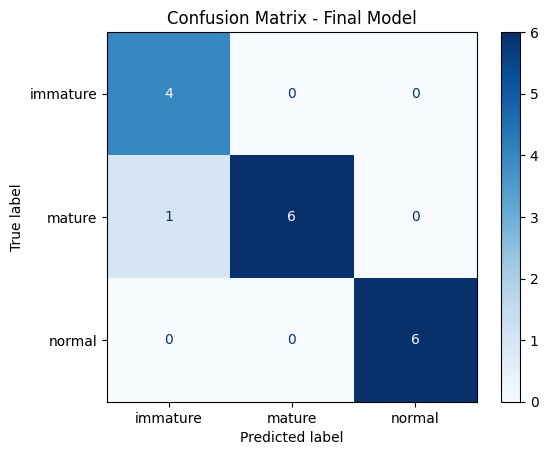

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Final Model")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

    immature       0.80      1.00      0.89         4
      mature       1.00      0.86      0.92         7
      normal       1.00      1.00      1.00         6

    accuracy                           0.94        17
   macro avg       0.93      0.95      0.94        17
weighted avg       0.95      0.94      0.94        17



In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_true, y_pred)
print(f"Akurasi Akhir Model: {acc:.4f}")

Akurasi Akhir Model: 0.9412


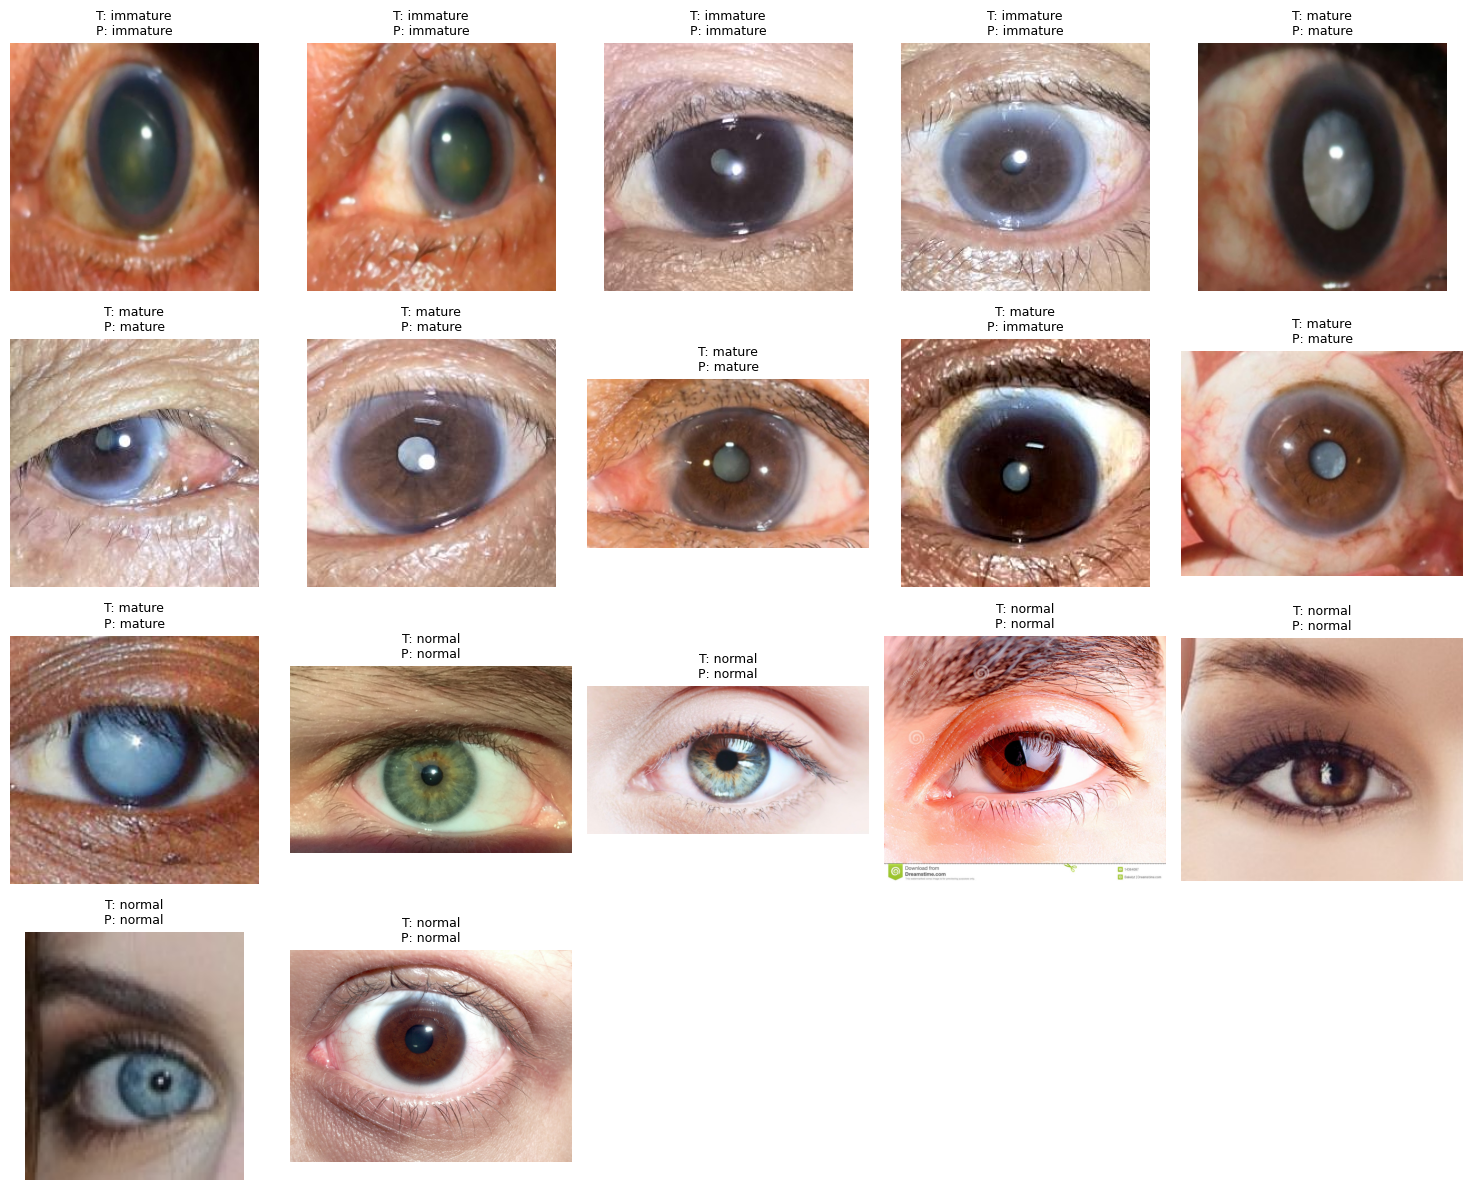

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.resnet50 import preprocess_input

num_images = len(test_data.filepaths)
cols = 5
rows = int(np.ceil(num_images / cols))

plt.figure(figsize=(15, 3 * rows))

for i in range(num_images):
    img_path = test_data.filepaths[i]
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    input_img = cv2.resize(img_rgb, (img_size, img_size))
    input_img = np.expand_dims(input_img.astype(np.float32), axis=0)
    input_img = preprocess_input(input_img)

    preds = model.predict(input_img, verbose=0)
    pred_class = np.argmax(preds)
    true_class = class_names[y_true[i]]

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img_rgb)
    plt.title(f"T: {true_class}\nP: {class_names[pred_class]}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

ADA INTERFACE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.models import load_model

model_path = "/content/drive/MyDrive/sindikia_ta/newdataset/bestmodel.h5"
model = load_model(model_path)
print("Model loaded")

Model loaded


In [ ]:
!pip install -q gradio

import gradio as gr
import numpy as np
import cv2
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = 224
class_names = class_names

def predict_image(img):
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_array = np.expand_dims(img_resized.astype(np.float32), axis=0)
    img_array = preprocess_input(img_array)

    preds = model.predict(img_array, verbose=0)
    pred_class = np.argmax(preds)

    return class_names[pred_class]

interface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="numpy"),
    outputs=gr.Text(),
    title="Klasifikasi Tingkat Maturitas Katarak (Cataract Maturity Classification)",
    description="Upload gambar mata untuk memprediksi tingkat maturitas katarak"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2928385f4796b88515.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
